In [10]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, hilbert, find_peaks
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft


In [6]:
# Sampling frequency and data path
fs = 2500  # Adjust according to your real sampling rate
file_path = 'recording.npy'

# Load the LFP recording
lfp_data = np.load(file_path)

# Channel assignment (Using only the detection channel from the hippocampus)
# If the file has multiple channels, select the correct index (e.g., 0)
if lfp_data.ndim > 1:
    hippocampus_channel = lfp_data[:, 0]
else:
    hippocampus_channel = lfp_data

# Create time vector
time_array = np.linspace(0, len(hippocampus_channel) / fs, len(hippocampus_channel))

In [7]:
# Create the main DataFrame for raw signal exploration (Single Channel)
df_exploration = pd.DataFrame({
    'Time (s)': time_array,
    'Hippocampus_CH': hippocampus_channel
}).set_index('Time (s)')

print("=== LFP DATAFRAME PREVIEW ===")
display(df_exploration.head(10))

print("\n=== DATA DESCRIPTIVE STATISTICS ===")
display(df_exploration.describe())

=== LFP DATAFRAME PREVIEW ===


,Hippocampus_CH
Time (s),
0.0000,24.642002
0.0004,-49.990341
0.0008,-37.032299
0.0012,-30.686247
0.0016,-19.050938
0.0020,-43.324875
0.0024,-34.755360
0.0028,-36.166695
0.0032,-39.428268



=== DATA DESCRIPTIVE STATISTICS ===


,Hippocampus_CH
count,775025.000000
mean,3.507274
std,86.557816
min,-835.004822
25%,-26.701138
50%,3.653075
75%,34.002682
max,883.067566


In [16]:
def compute_swr_metrics(lfp_channel, fs=2500):
    time = np.linspace(0, len(lfp_channel)/fs, len(lfp_channel))
    
    # 1. Bandpass filtering (Ripple 100-250 Hz and Control bands)
    b_ripple, a_ripple = butter(4, [100, 250], btype='bandpass', fs=fs)
    ripple_band = filtfilt(b_ripple, a_ripple, lfp_channel)
    
    b_ctrl, a_ctrl = butter(4, [200, 500], btype='bandpass', fs=fs)
    control_band = filtfilt(b_ctrl, a_ctrl, lfp_channel)
    
    # 2. Hilbert transform for instantaneous envelopes and phase
    analytic_ripple = hilbert(ripple_band)
    envelope = np.abs(analytic_ripple)
    phase_unwrapped = np.unwrap(np.angle(analytic_ripple))
    
    ctrl_envelope = np.abs(hilbert(control_band))
    
    # 3. Detection thresholds
    median_env = np.median(envelope)
    threshold = 5 * median_env
    half_threshold = 2.5 * median_env
    
    # Peak detection (retaining only the highest peak within 20ms frames)
    min_distance_samples = int(0.020 * fs) 
    peaks, _ = find_peaks(envelope, height=threshold, distance=min_distance_samples)
    
    candidate_events = []
    
    # 4. Feature extraction per candidate event
    for peak in peaks:
        onset, offset = peak, peak
        while onset > 0 and envelope[onset] >= half_threshold: onset -= 1
        while offset < len(envelope) - 1 and envelope[offset] >= half_threshold: offset += 1
            
        duration = (offset - onset) / fs
        if duration <= 0: continue
            
        phase_diff_deg = np.degrees(phase_unwrapped[offset] - phase_unwrapped[onset])
        cycles = phase_diff_deg / 360.0
        mean_freq = cycles / duration
        
        ripple_power = (np.mean(envelope[onset:offset])) ** 2
        ctrl_power = (np.mean(ctrl_envelope[onset:offset])) ** 2
        
        # 5. Validation checks
        check_2 = mean_freq > 100
        check_3 = cycles >= 4
        check_4 = ripple_power >= (2 * ctrl_power)
        
        is_valid_swr = check_2 and check_3 and check_4
        
        candidate_events.append({
            'Peak_Sample': peak,
            'Onset_Time(s)': time[onset],
            'Offset_Time(s)': time[offset],
            'Duration(s)': duration,
            'Cycles': cycles,
            'Mean_Freq(Hz)': mean_freq,
            'Ripple_Power': ripple_power,
            'Ctrl_Power': ctrl_power,
            'Is_Valid_SWR': is_valid_swr
        })
        
    return pd.DataFrame(candidate_events), ripple_band, envelope

In [17]:
# Process the signal using the defined single-channel algorithm
df_events, ripple_band, envelope = compute_swr_metrics(hippocampus_channel, fs=fs)

# Print detection summaries
print(f"Total candidate events detected (exceeded 5x median): {len(df_events)}")

# Filter true SWR events that pass the remaining 3 strict criteria
true_swrs = df_events[df_events['Is_Valid_SWR'] == True].copy()
print(f"Validated SWR events (passed all remaining criteria): {len(true_swrs)}")

print("\n=== SWR EVENTS DATAFRAME PREVIEW ===")
display(true_swrs.head(10))

Total candidate events detected (exceeded 5x median): 127
Validated SWR events (passed all remaining criteria): 38

=== SWR EVENTS DATAFRAME PREVIEW ===


,Peak_Sample,Onset_Time(s),Offset_Time(s),Duration(s),Cycles,Mean_Freq(Hz),Ripple_Power,Ctrl_Power,Is_Valid_SWR
4,85545,34.211644,34.246444,0.0348,5.473848,157.294488,624.453801,99.498106,True
12,209597,83.815708,83.844908,0.0292,5.396519,184.812279,1316.455629,278.965668,True
15,220330,88.118914,88.152514,0.0336,5.710130,169.944350,575.586614,106.004003,True
17,229165,91.657318,91.687318,0.0300,5.351383,178.379429,639.126434,108.377936,True
19,236971,94.772122,94.806922,0.0348,6.432734,184.848684,583.951928,161.925895,True
23,240290,96.094924,96.140924,0.0460,8.254496,179.445566,519.800499,139.819111,True
27,245887,98.342927,98.364927,0.0220,4.225829,192.083144,732.973442,214.261187,True
30,306104,122.426558,122.456958,0.0304,5.088214,167.375461,533.410640,117.706968,True
31,306237,122.486558,122.512158,0.0256,4.460147,174.224495,506.317971,122.399632,True
36,367474,146.976190,147.010590,0.0344,6.427044,186.832673,1321.024156,296.798388,True


In [ ]:
def nextpow2(i):
    n = 1
    while n < i: n *= 2
    return n

def closest(X, p):
    disp = X - p
    return np.argmin((disp*disp))

def cohen_cwt(signal, fs, freq_limits, num_frex, cycles_limits):
    time = np.arange(-2, 2 + 1/fs, 1/fs)
    frex = np.logspace(np.log10(freq_limits[0]), np.log10(freq_limits[1]), num_frex)
    s = np.logspace(np.log10(cycles_limits[0]), np.log10(cycles_limits[1]), num_frex) / (2 * np.pi * frex)

    n_wavelet = len(time)
    n_data = len(signal)
    n_convolution = n_wavelet + n_data - 1
    n_conv_pow2 = nextpow2(n_convolution)
    half_of_wavelet_size = n_wavelet // 2

    eegfft = fft(signal.values if isinstance(signal, pd.Series) else signal, n_conv_pow2)
    eegpower = np.zeros((num_frex, n_data))

    for fi in range(num_frex):
        wavelet = fft(
            np.sqrt(1 / (s[fi] * np.sqrt(np.pi))) *
            np.exp(2 * 1j * np.pi * frex[fi] * time) *
            np.exp(-time**2 / (2 * s[fi]**2)),
            n_conv_pow2
        )
        eegconv = ifft(wavelet * eegfft)
        eegconv = eegconv[:n_convolution]
        eegconv = eegconv[half_of_wavelet_size:-half_of_wavelet_size]
        eegpower[fi, :] = np.abs(eegconv)**2

    return frex, eegpower

def plot_eeg_spectrogram_on_ax(ax, power, freqs, time_range, vmin, vmax, hline_range):
    """Plots a linear frequency spectrogram."""
    # Plot power directly on a linear scale
    im = ax.imshow(np.log10(power), # Log power for color visibility
                   aspect='auto', origin='lower',
                   extent=[time_range[0], time_range[1], freqs.min(), freqs.max()],
                   vmin=vmin, vmax=vmax, cmap='jet')

    # Set linear frequency ticks
    ax.set_ylim(freqs.min(), freqs.max())
    
    # Horizontal lines
    ax.axhline(hline_range[0], color='w', linestyle='--', linewidth=3)
    ax.axhline(hline_range[1], color='w', linestyle='--', linewidth=3)

def plot_ripple_event_series(df_all, ripple_times, fs=2500, v_limit=(5, 7), height=None):
    for idx in range(len(ripple_times)):
        r_range = ripple_times.iloc[idx]
        
        duration = r_range['Offset_Time(s)'] - r_range['Onset_Time(s)']
        factor = (1 - duration) / 2
        t_start = r_range['Onset_Time(s)'] - factor
        t_end = r_range['Offset_Time(s)'] + factor

        df_chunk = df_all[(df_all['time'] >= t_start) & (df_all['time'] <= t_end)]

        fig, axs = plt.subplots(4, 1, figsize=(20, 15))
        # Changed 'Smooth' to 'Envelope' in list
        signals = ['Raw', 'Filtered', 'Envelope'] 

        for i, col in enumerate(signals):
            axs[i].plot(df_chunk['time'], df_chunk[col], color='black')
            
            # Gray shaded region
            axs[i].axvspan(r_range['Onset_Time(s)'], r_range['Offset_Time(s)'], 
                           color='gray', alpha=0.3, lw=0, zorder=0)

            if col == 'Raw':
                axs[i].set_title(f"   {col}", loc='left', fontsize=20)
            elif col == 'Envelope':
                axs[i].set_title("   Envelope", loc='left', fontsize=20) # Updated title
                if height is not None:
                    axs[i].axhline(height, color='black', linestyle='--')
            else:
                axs[i].set_title("   Filtered (100-250 Hz)", loc='left', fontsize=20)

            axs[i].set_ylabel('Amplitude (µV)', fontsize=15)
            for spine in ['right', 'top', 'bottom']:
                axs[i].spines[spine].set_visible(False)
            axs[i].xaxis.set_visible(False)
            axs[i].tick_params(axis='both', which='major', labelsize=12)

        # Spectrogram parameters
        num_frex = 50
        cycles_limits = (7, 14)
        # Analyzing 50-300Hz
        frex, eegpower = cohen_cwt(df_chunk['Raw'], fs, (50, 300), num_frex, cycles_limits)

        # Linear spectrogram
        plot_eeg_spectrogram_on_ax(axs[3], eegpower, frex,
                                   time_range=(t_start, t_end),
                                   vmin=v_limit[0], vmax=v_limit[1],
                                   hline_range=(100, 250)) 

        axs[3].set_title("   Spectrogram", loc='left', fontsize=20)
        axs[3].set_ylabel('Frequency (Hz)', fontsize=15)
        axs[3].set_xlabel('Time (s)', fontsize=15)
        axs[3].tick_params(axis='both', which='major', labelsize=12)

        plt.suptitle(f'Ripple {idx+1}', y=0.95, fontsize=25)
        plt.show()


Plotting the first 5 validated ripples...


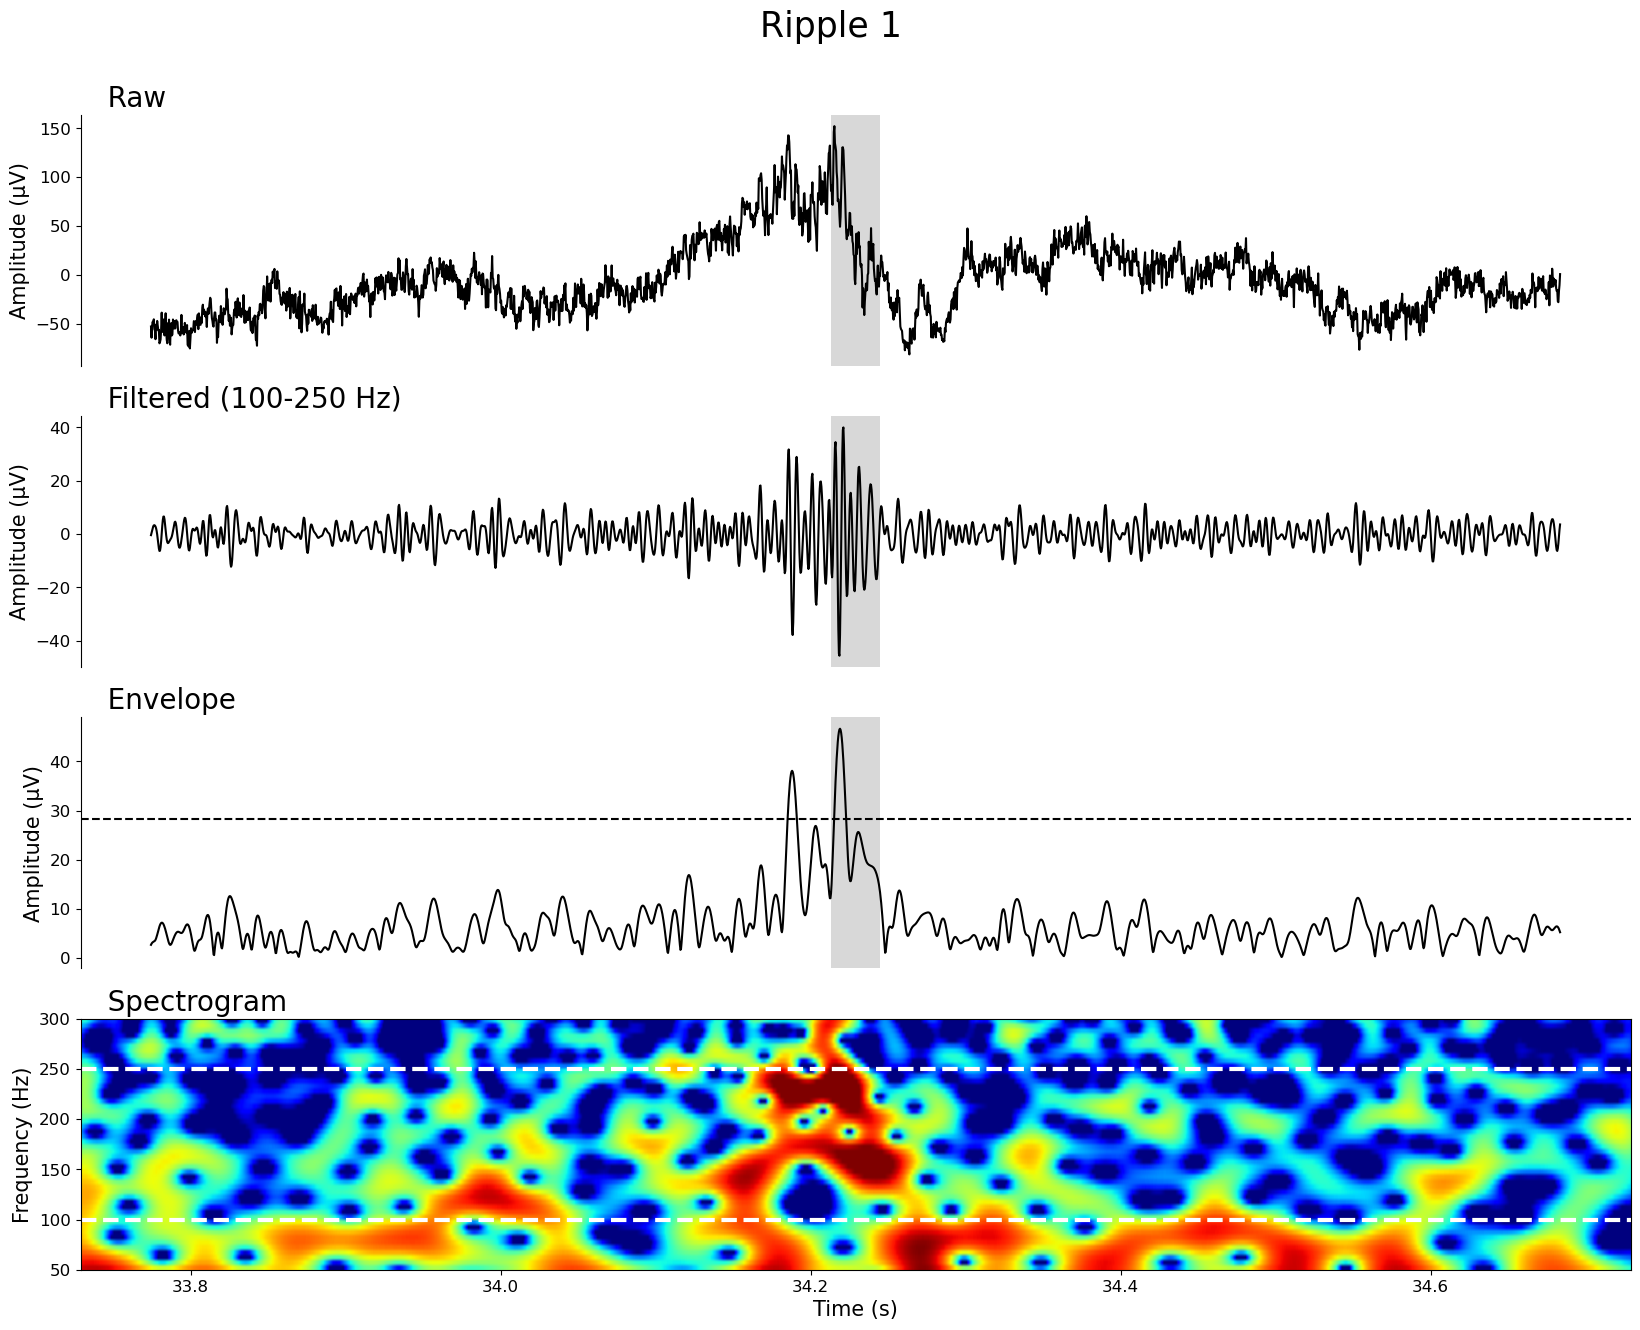

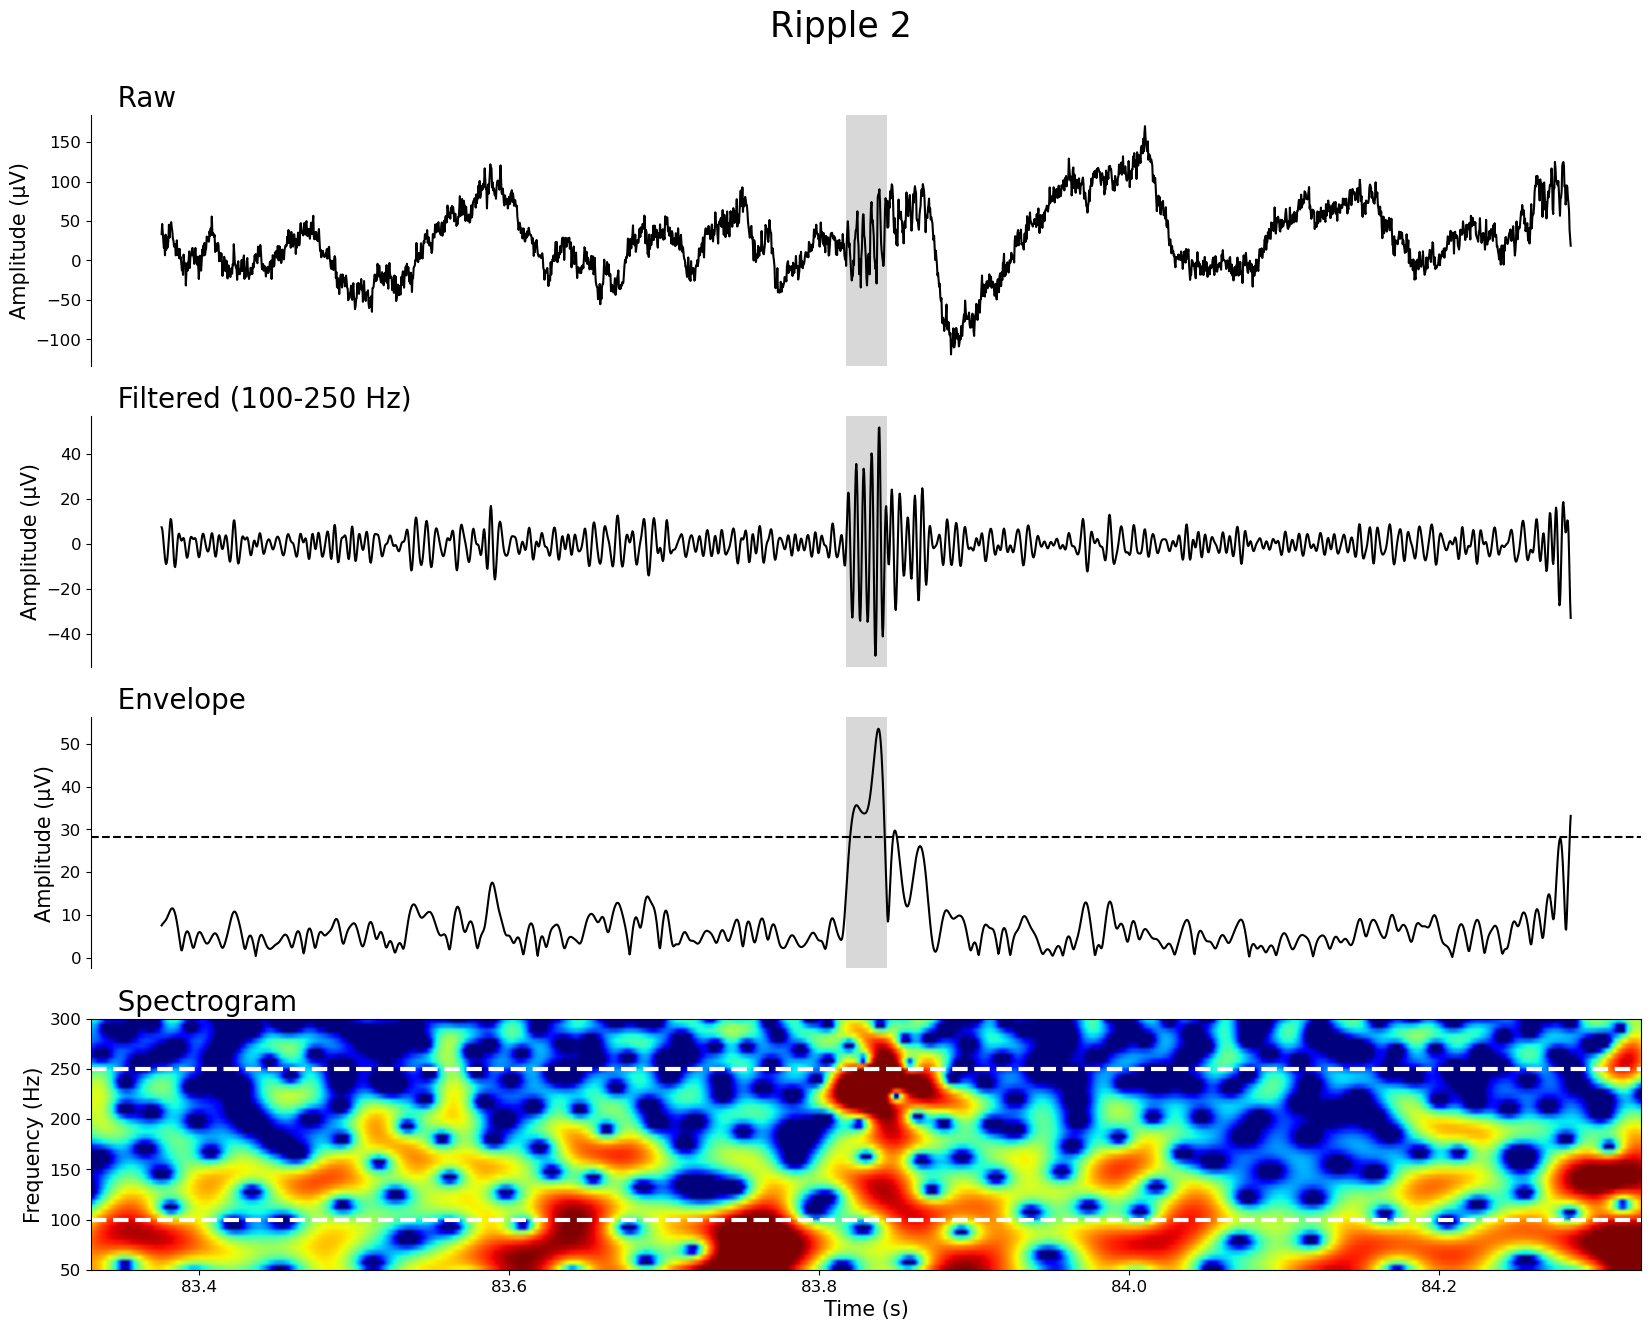

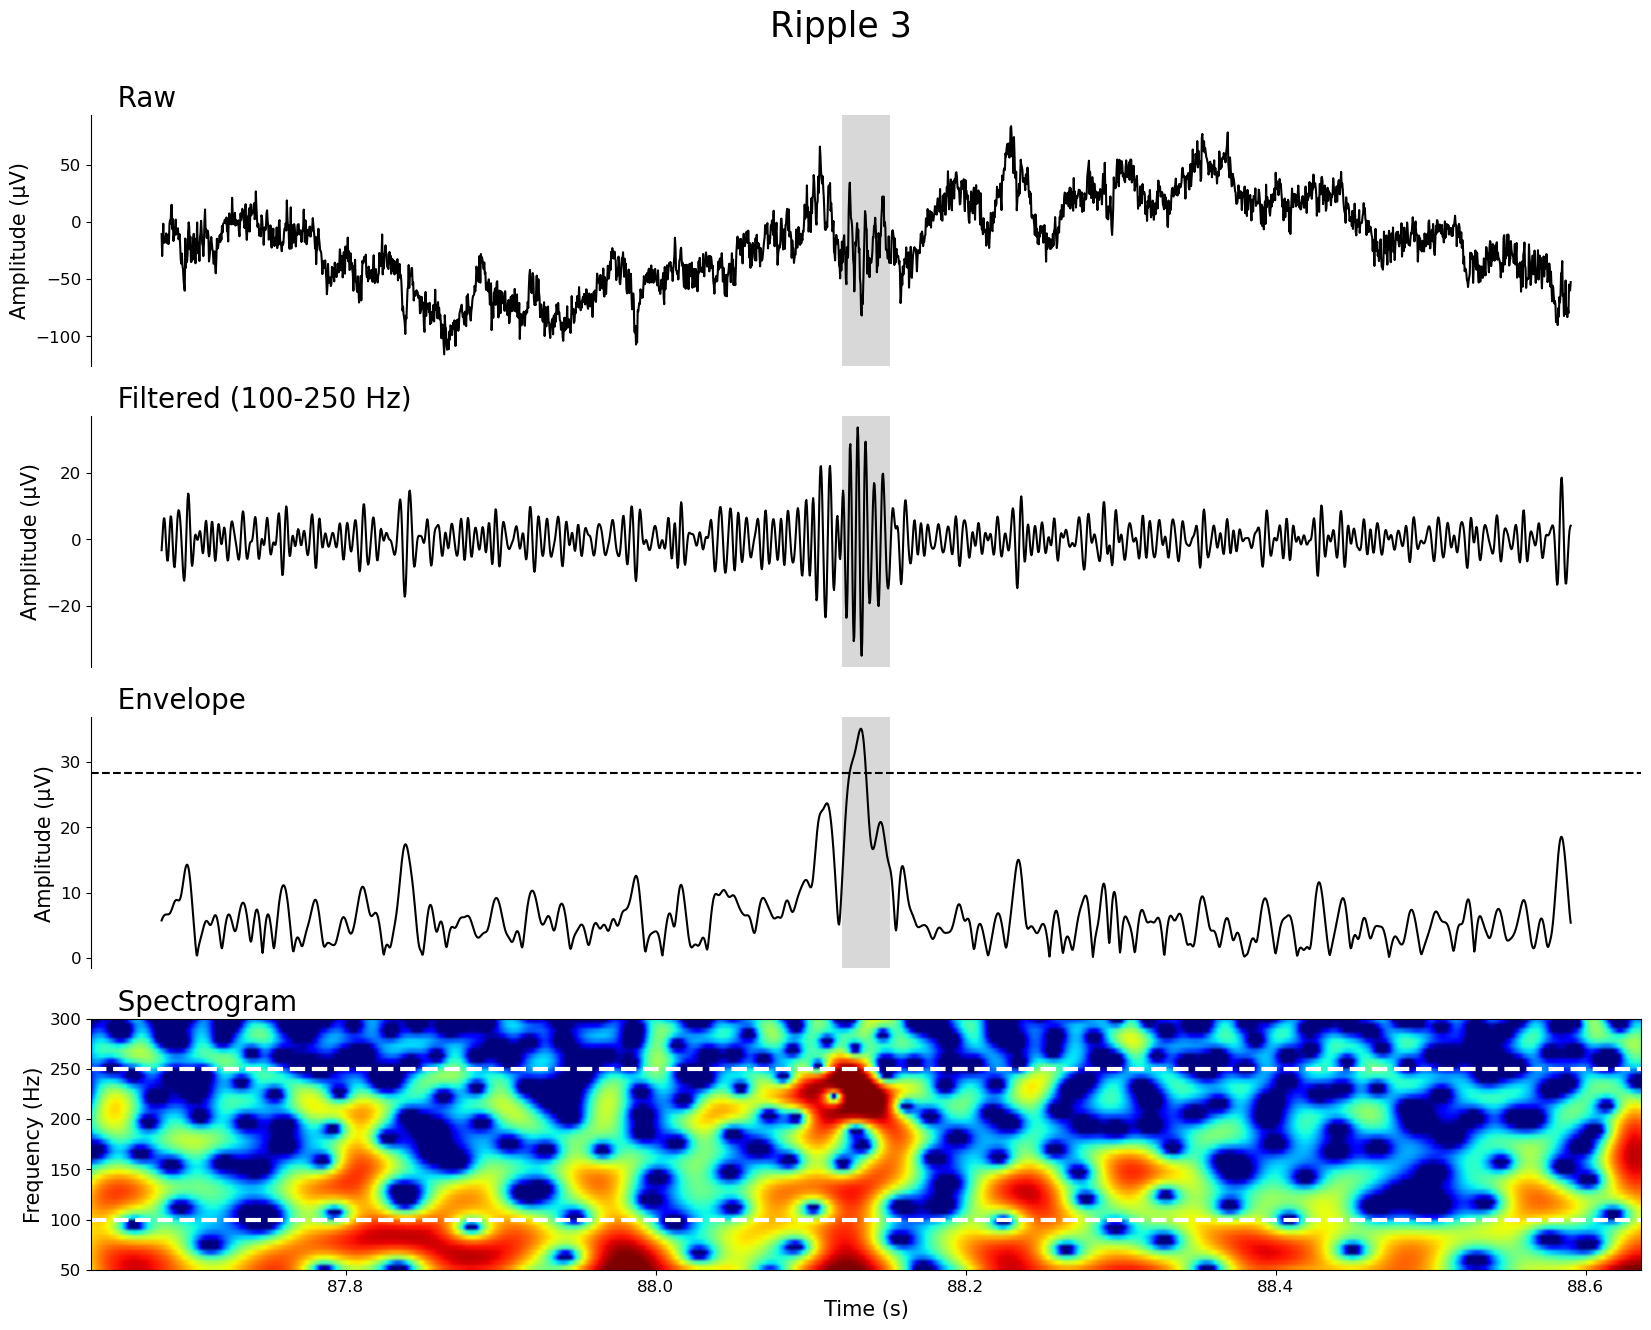

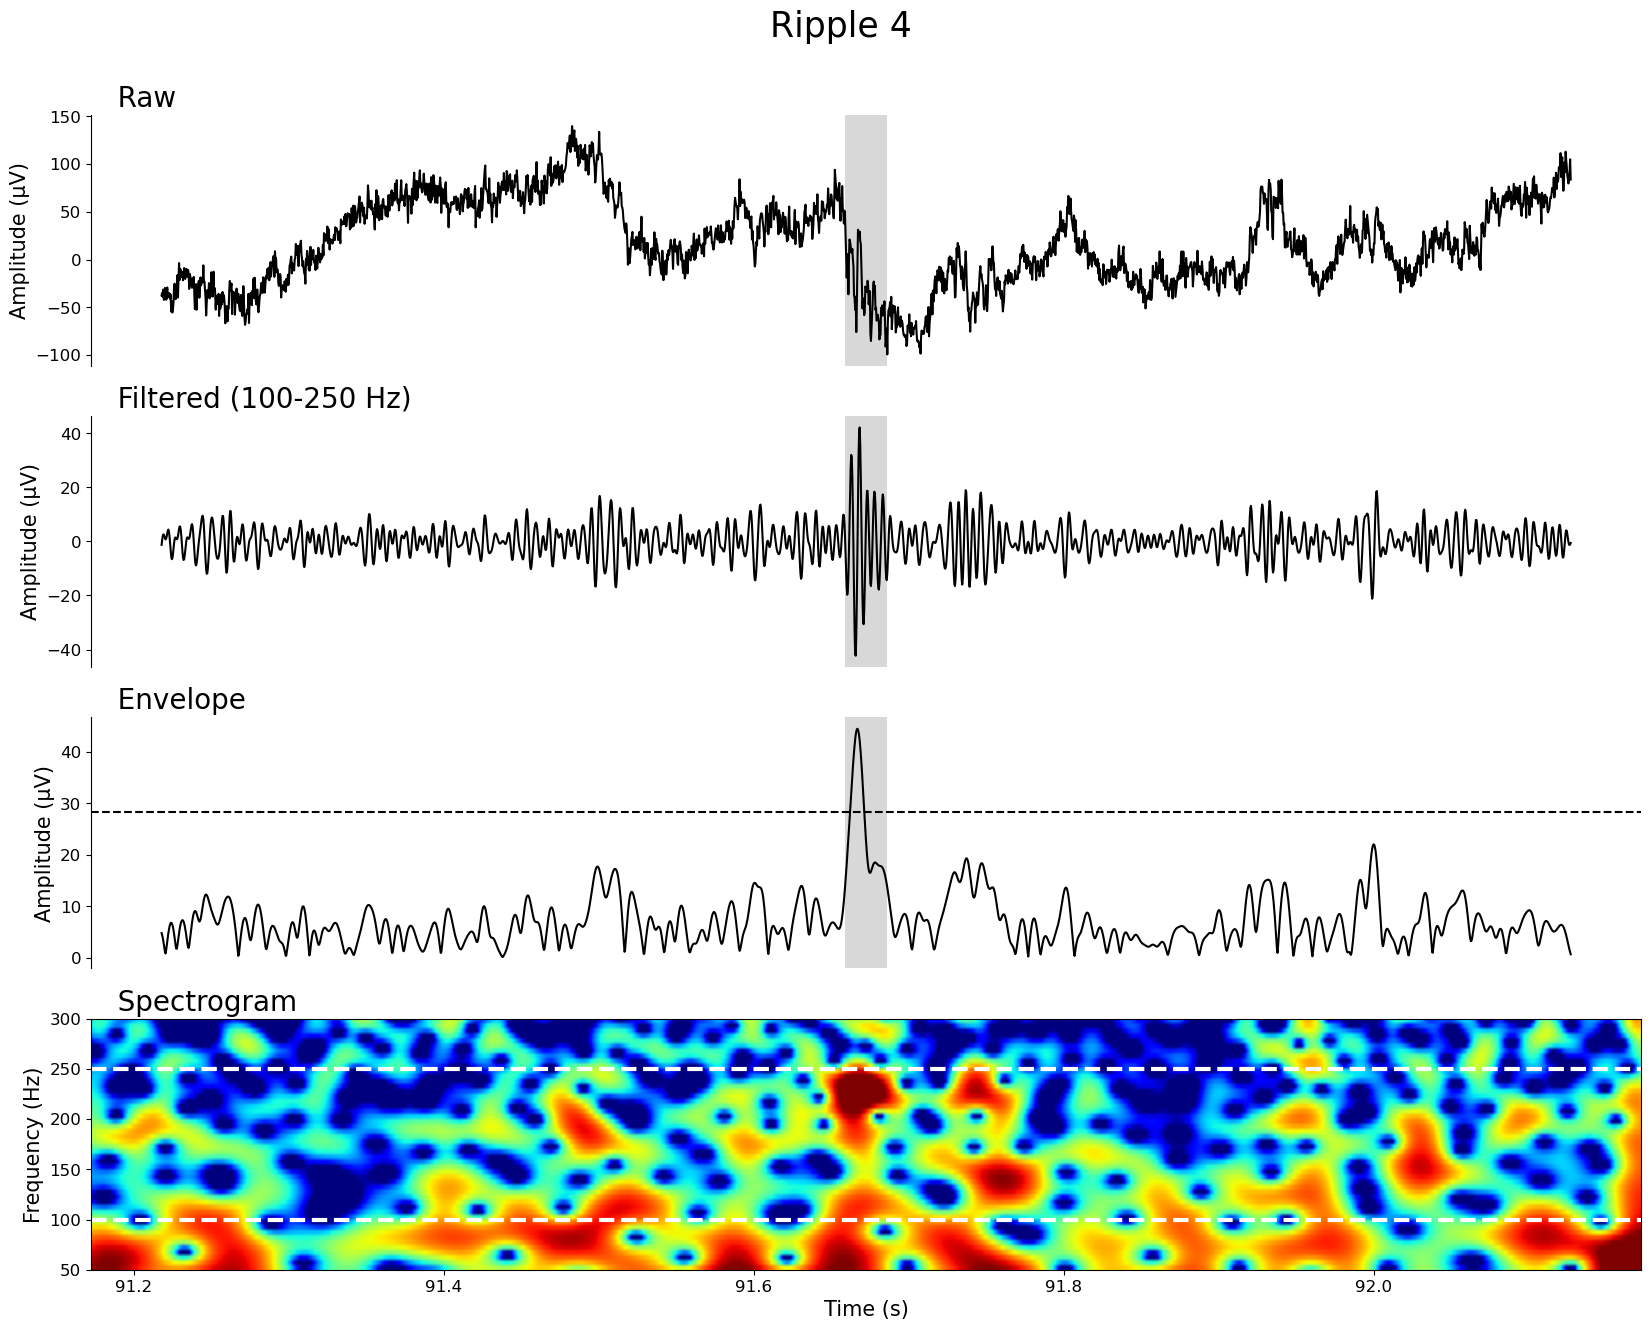

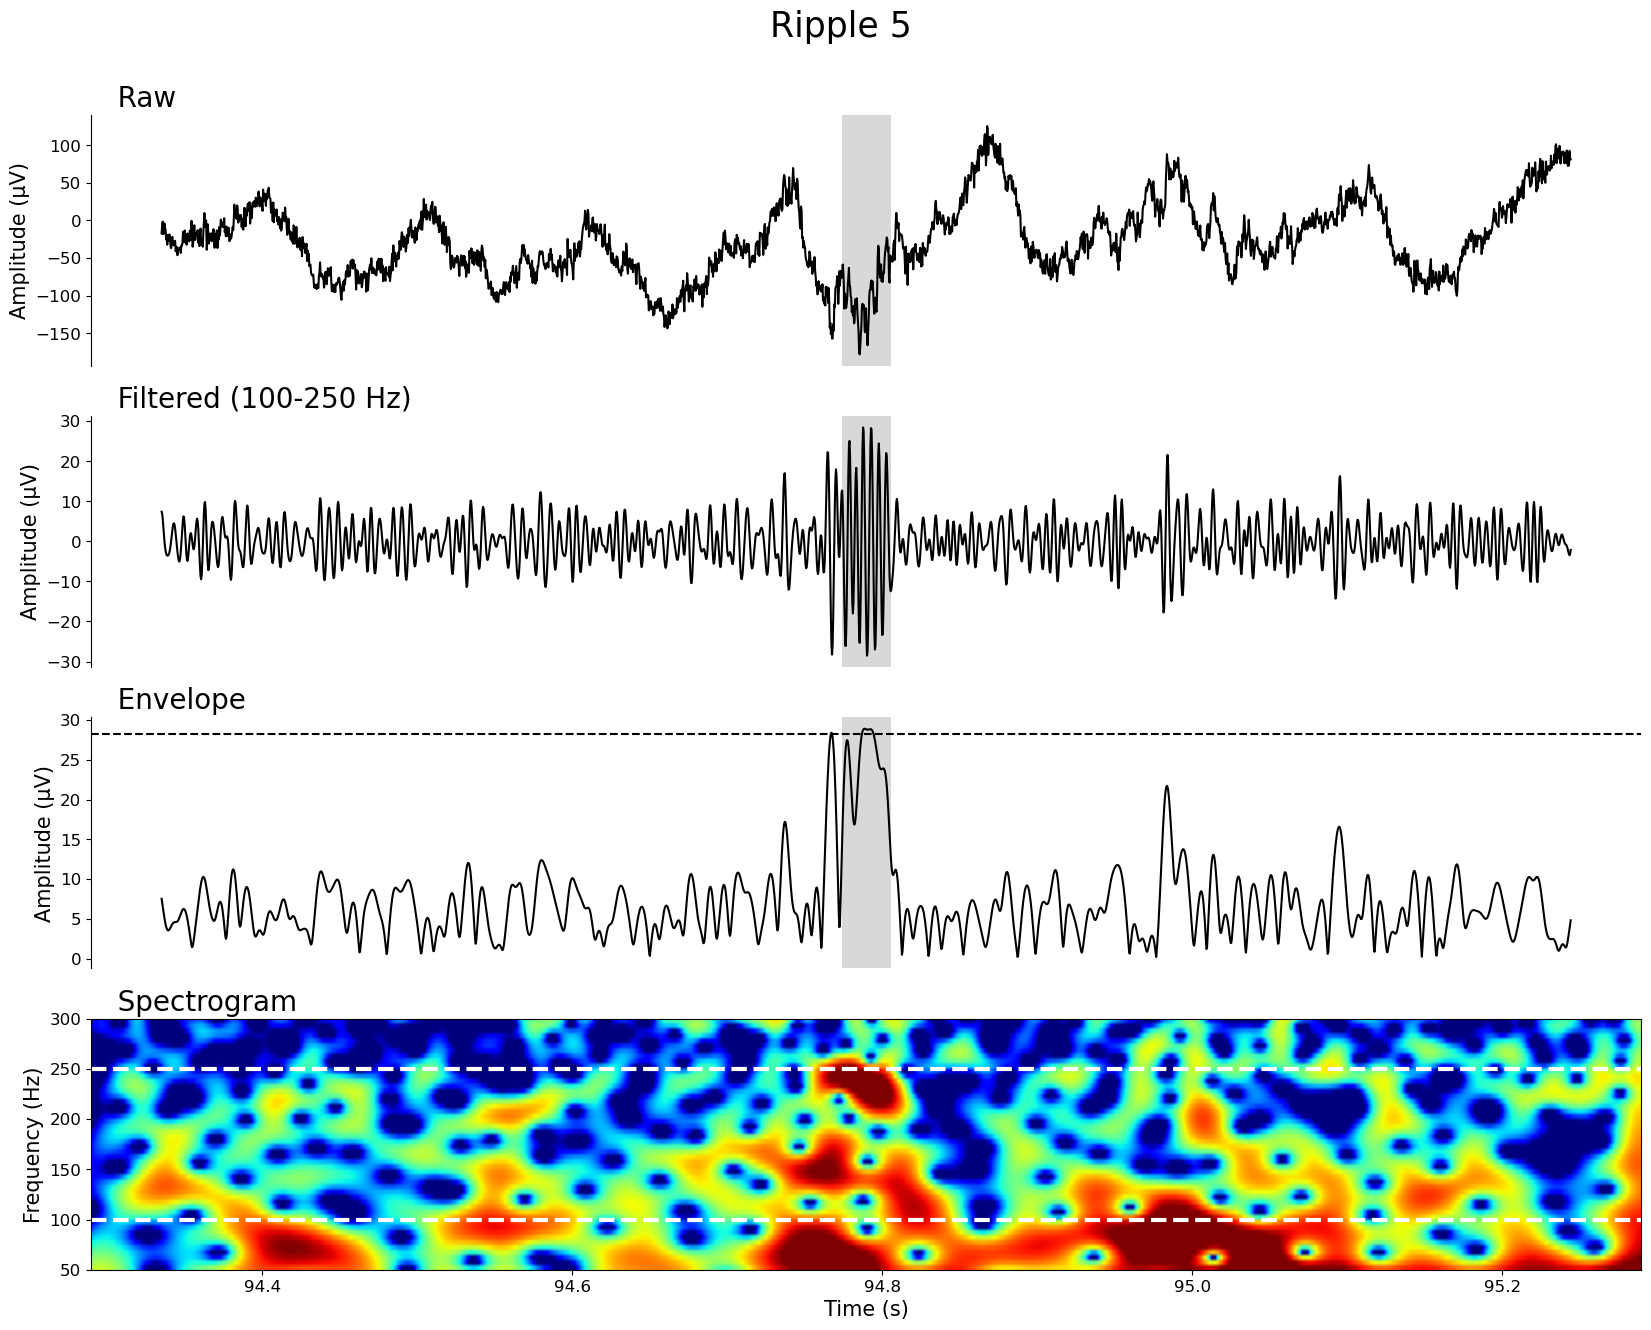

In [21]:
# 1. Prepare Full DataFrame using outputs from Cell 3
df_full_signals = pd.DataFrame({
    'time': time_array,
    'Raw': hippocampus_channel,
    'Filtered': ripple_band,
    'Envelope': envelope # Changed column name
})

# 2. Calculate plotting height threshold (5x median of the envelope)
detection_threshold = 5 * np.median(envelope)

# 3. Plot the first 5 detected ripples as an example
print(f"Plotting the first 5 validated ripples...")
plot_ripple_event_series(df_full_signals, 
                         true_swrs.head(5), 
                         fs=fs, 
                         height=detection_threshold)